### load Data 

In [1]:
import pandas as pd 
data=pd.read_csv('data.csv')
print(data.to_string())

      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0     7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL                   No                  Yes                   No                   No                   No                   No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1     5575-GNVDE    Male              0      No         No      34          Yes                No             DSL                  Yes                   No                  Yes                   No                   No                   No        One year               No               Mailed check           56.95       1889.5  

### Data Analyze and first look 

In [2]:
print(data.head().to_string())
print('data shape is : ',data.shape)
print('the culumns are : ',data.columns)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes  

In [3]:
# infos and discription :
print('quelque informations sur notre data : \n',data.info())
print('la description du data est :\n ',data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#find missing values :
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
print(data.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [6]:
# turn TotalCharges numeric since it was an object 
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())
print(data['TotalCharges'].isna().sum())

0


### visualisations

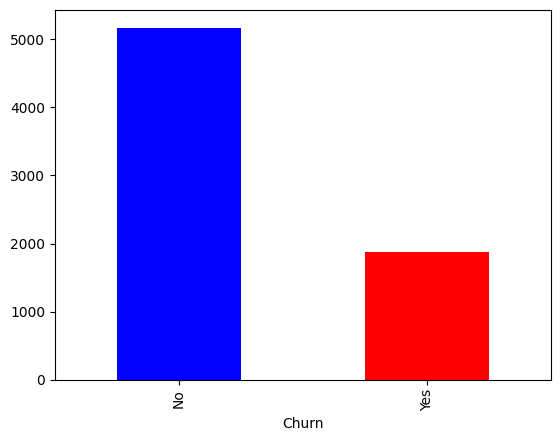

In [7]:
#see how many people disabanded 
import matplotlib.pyplot as plt 
y=data['Churn'].value_counts()
data['Churn'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.show()

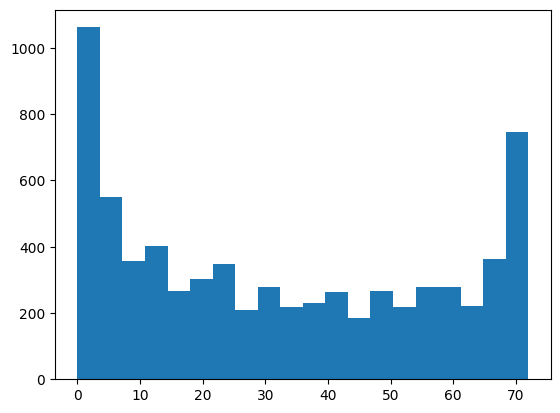

In [8]:
#tenure 
plt.hist(data['tenure'],bins=20)
plt.show()

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


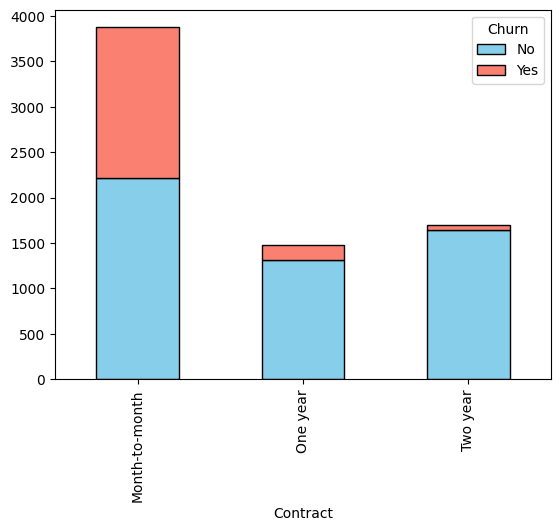

In [9]:
# relation between Contract and Churn 
cross = pd.crosstab(data['Contract'], data['Churn'])
print(cross)
cross.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], edgecolor='black')
plt.show()

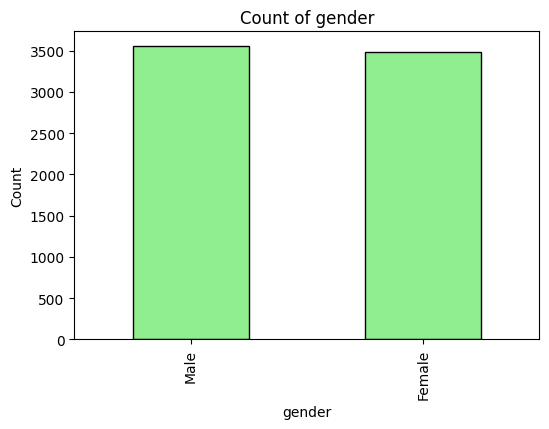

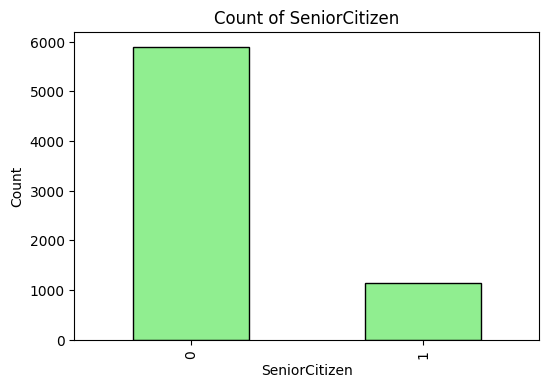

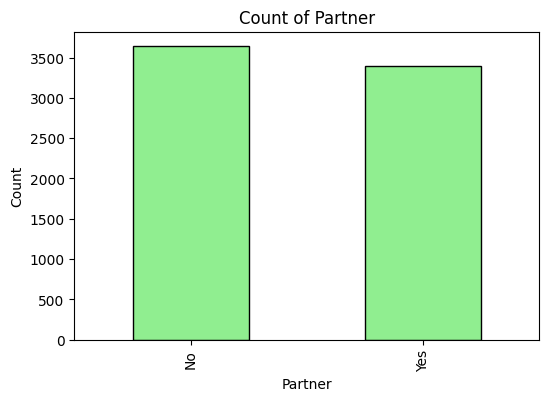

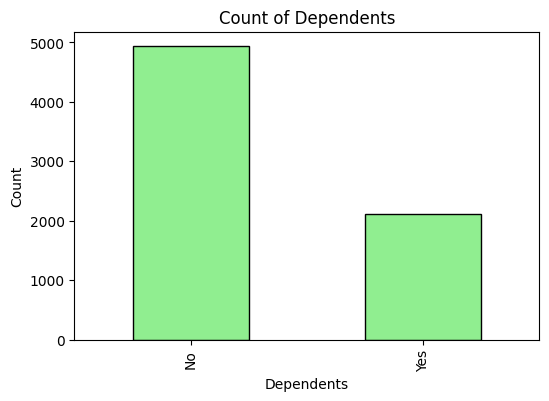

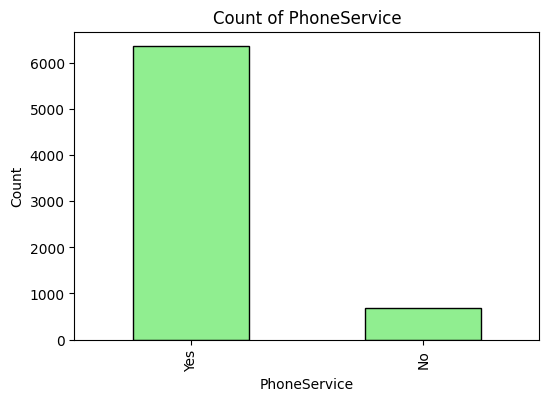

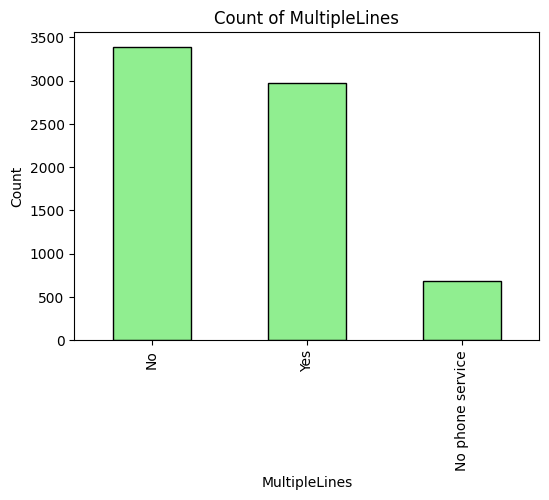

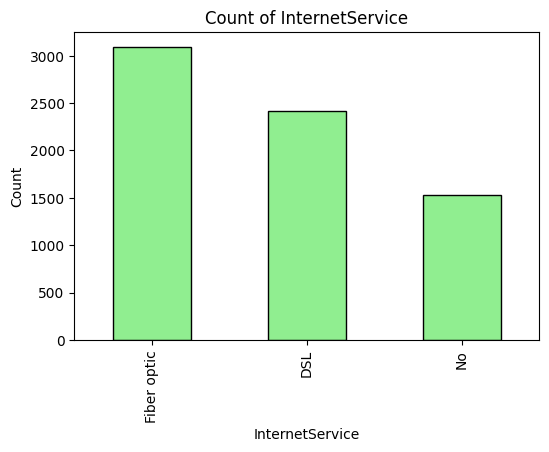

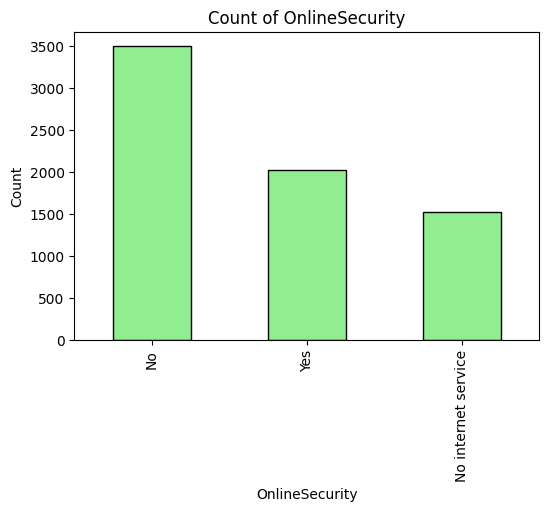

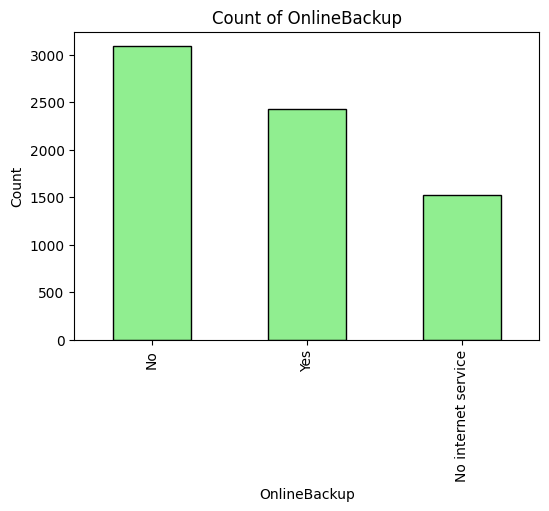

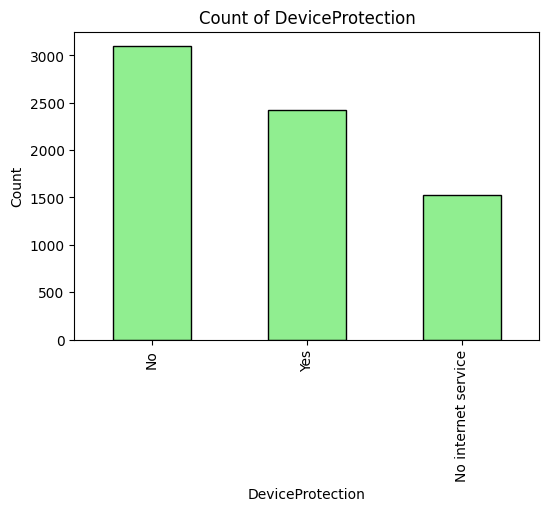

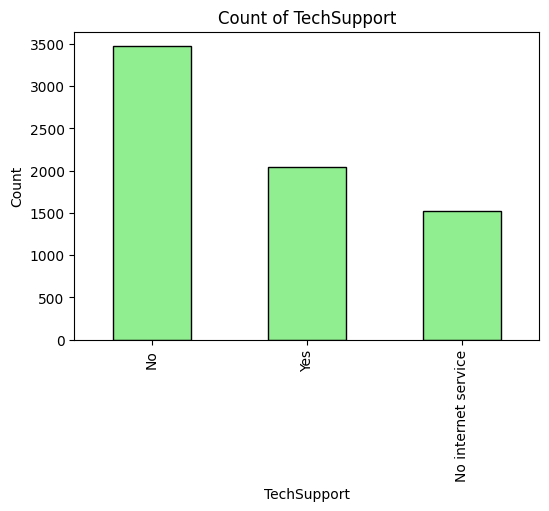

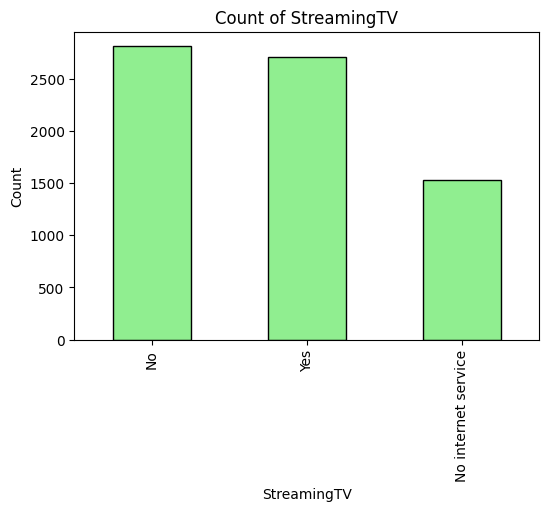

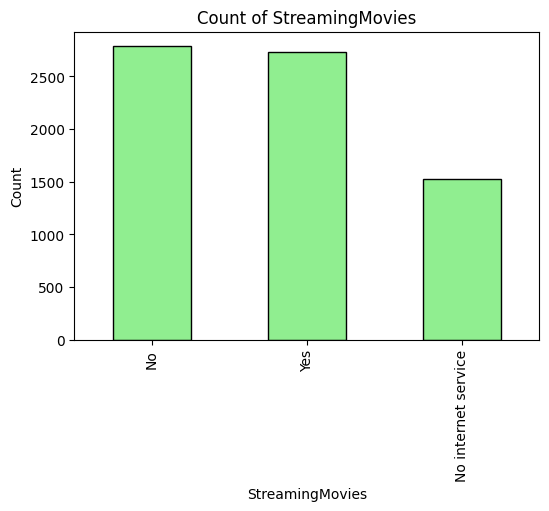

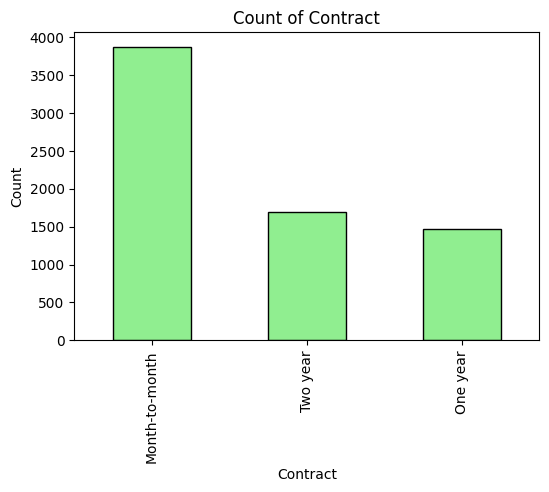

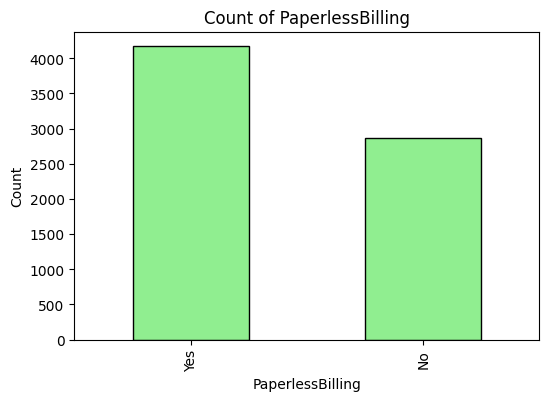

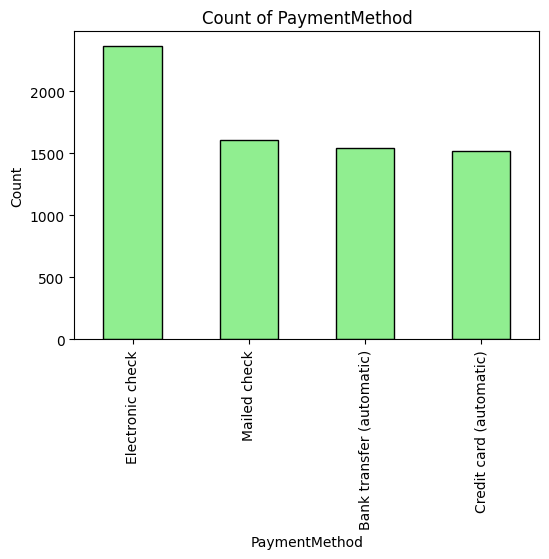

In [10]:
#categorical 
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    data[col].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

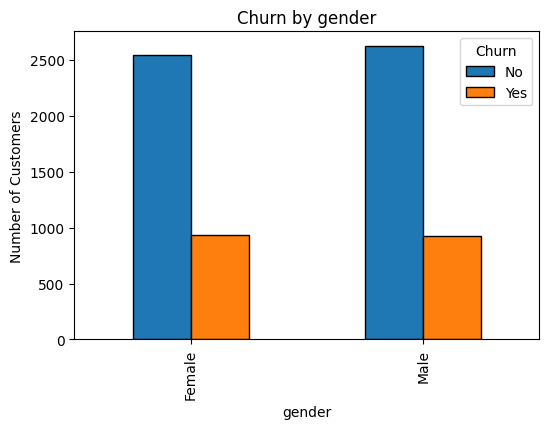

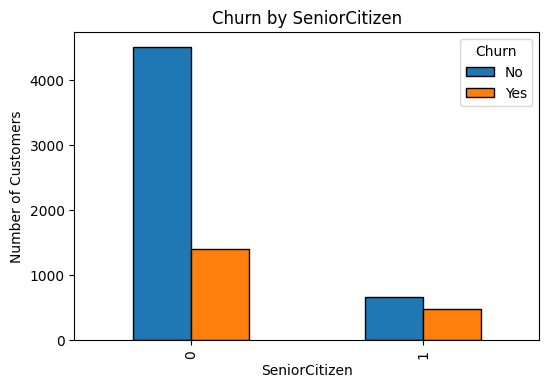

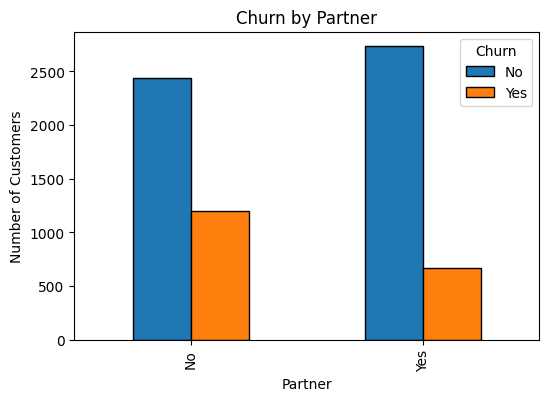

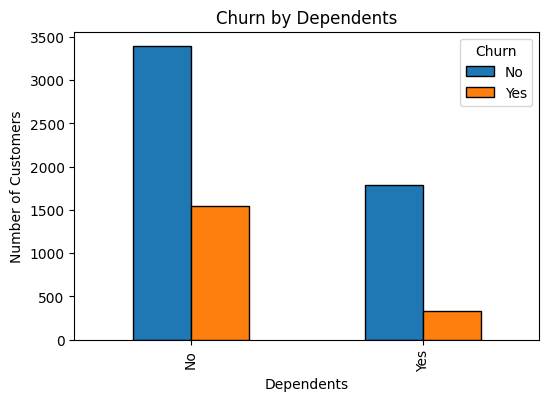

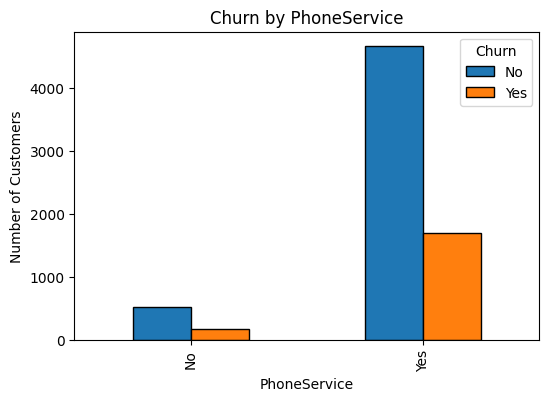

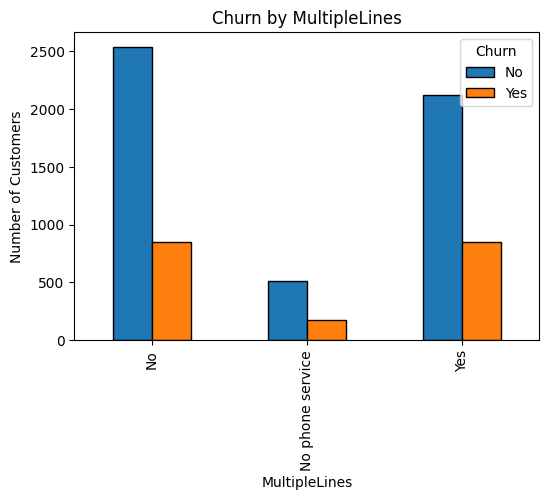

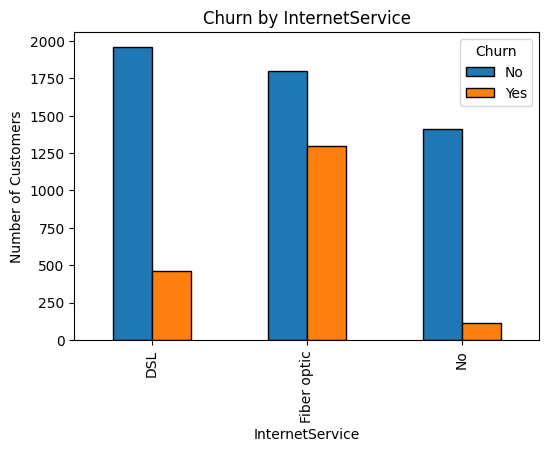

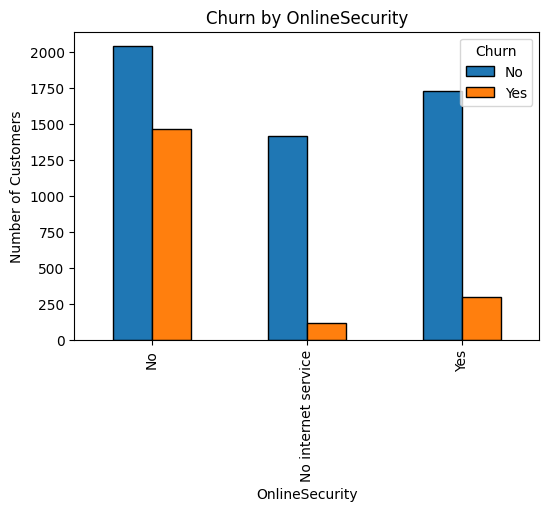

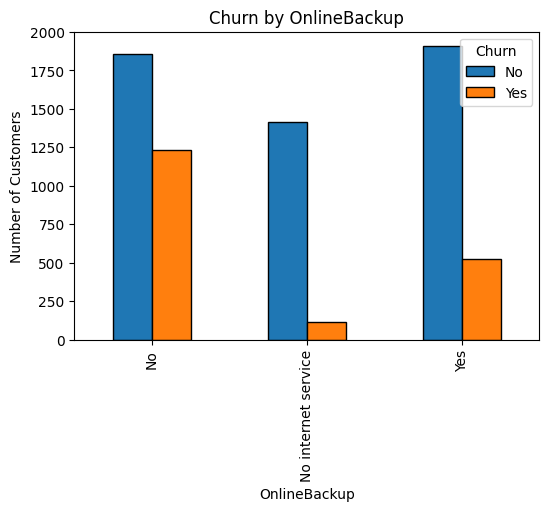

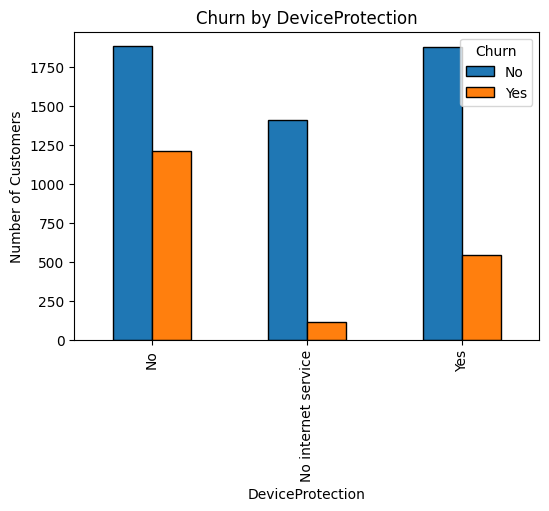

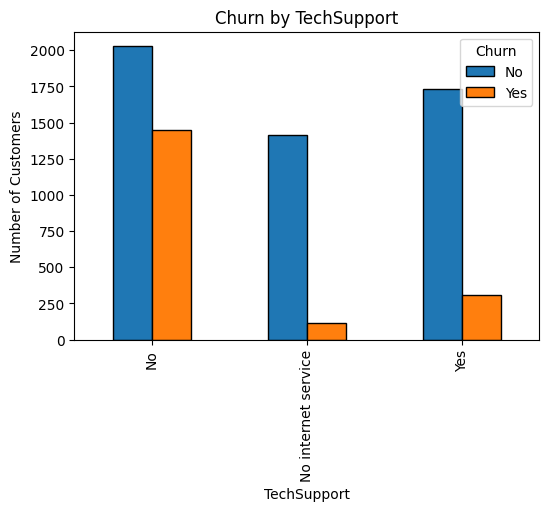

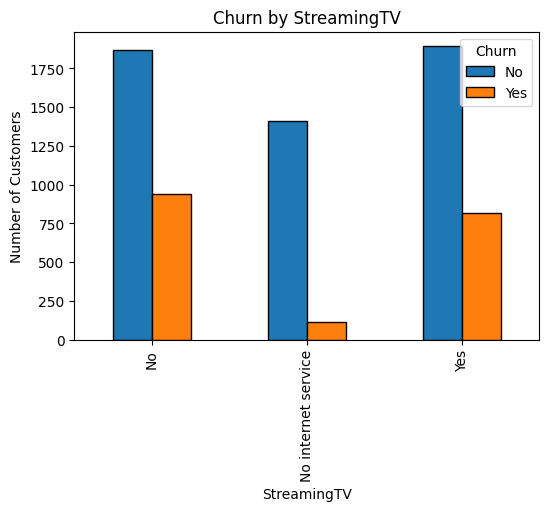

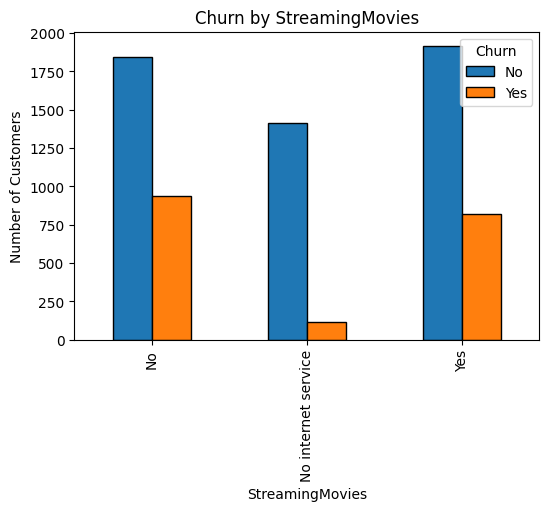

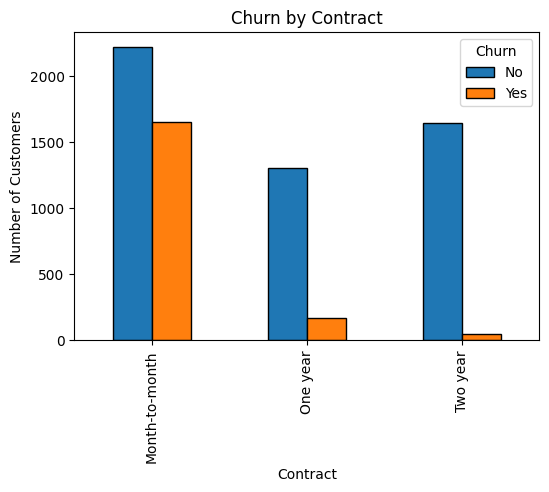

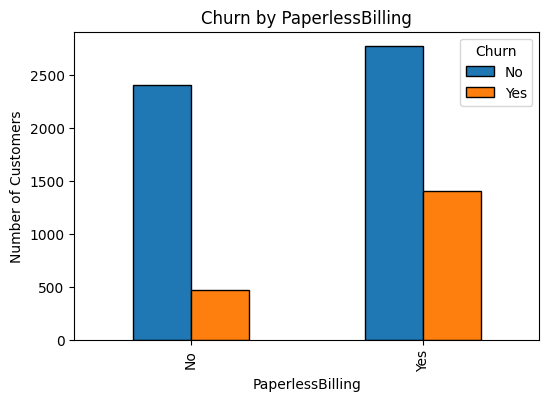

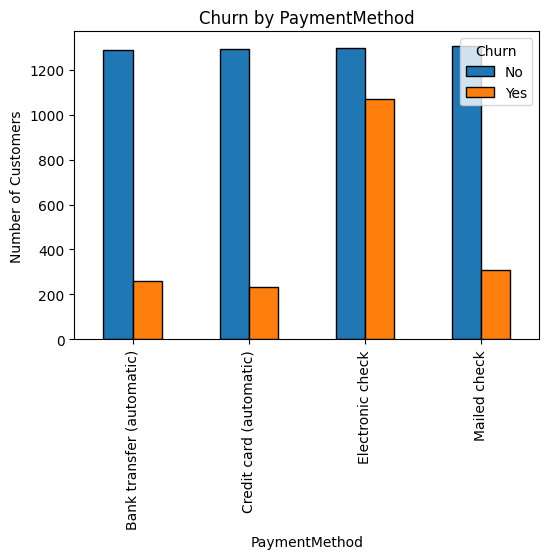

In [11]:
#Compare Categorical Columns with Churn
for col in categorical_cols:
    churn_group = data.groupby([col, 'Churn']).size().unstack()
    churn_group.plot(kind='bar', figsize=(6,4), edgecolor='black')
    plt.title(f"Churn by {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.legend(title='Churn', loc='upper right')
    plt.show()

<Axes: xlabel='SeniorCitizen', ylabel='count'>

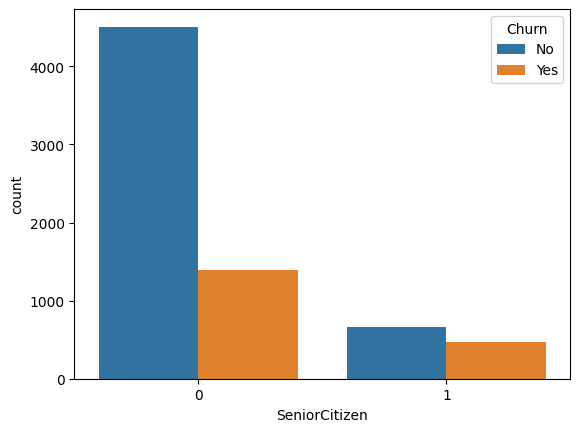

In [12]:
# churn with seniorCitizen
import seaborn as sns
sns.countplot(data=data,x='SeniorCitizen',hue='Churn')



In [13]:
# transform yes/no columns:
# yes_no_cols = ['Partner', 'Dependents','PhoneService','PaperlessBilling','Churn']
# for col in yes_no_cols:
#      data[col] = data[col].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})
# data['gender']=data['gender'].map({'Female':1,'Male':0})
data['Churn']=data['Churn'].map({'Yes':1,'No':0})

In [14]:
# transform all data to numeric 
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# cat_columns=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
#         'TechSupport','InternetService', 'StreamingTV', 'StreamingMovies', 'MultipleLines','Contract','PaymentMethod']
# for col in cat_columns:
#     data[col] = le.fit_transform(data[col])
# data=data.drop(columns='customerID')

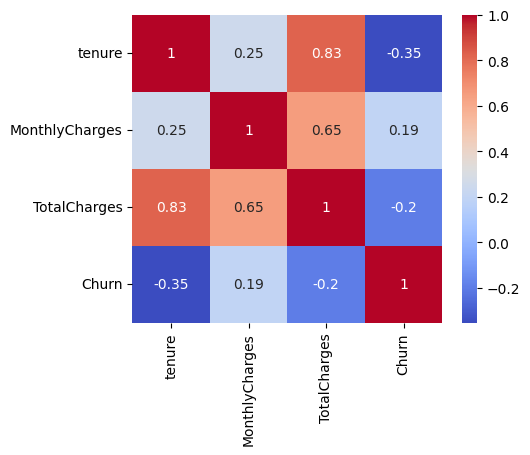

In [16]:
# correlation and matrice de correlation
import seaborn as sns
matrix = data[['tenure', 'MonthlyCharges', 'TotalCharges','Churn']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(matrix,annot=True,cmap='coolwarm')
plt.show()

